In [20]:
from typing import TypedDict
from langgraph.graph import StateGraph , START,END

In [21]:
class Pipeline(TypedDict):
    value : int

In [22]:
def add_one(state : Pipeline) ->dict:
    result = state['value']+1
    print(f'add {state['value']}--->{result}')
    return {'result':result}

In [23]:
def double(state : Pipeline) ->dict:
    result = state['value']*2
    print(f'double {state['value']}--->{result}')
    return {'result':result}

In [24]:
def square(state : Pipeline) ->dict:
    result = state['value']**2
    print(f'square {state['value']}---->{result}')
    return {'result':result}

In [25]:

builder = StateGraph(Pipeline)

In [26]:
builder.add_node("add",add_one)
builder.add_node("double",double)
builder.add_node("square",square)

In [27]:
builder.add_edge(START,"add")
builder.add_edge('add',"double")
builder.add_edge('double',"square")
builder.add_edge('square',END)

In [28]:
graph = builder.compile()

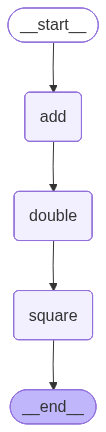

In [29]:
from IPython.display import Image, display

display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)

In [30]:
result = graph.invoke({'value':3})

print(result)

add 3--->4
double 3--->6
square 3---->9
{'value': 3}


# Conditional Edges

In [1]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END

In [2]:
class NumberState(TypedDict):
    number : int
    result : str


def recive_num(state : NumberState) ->dict:
    print(f'{state["number"]} recived')



In [3]:
def router_for_odd_or_even(state : NumberState)-> Literal['odd','even']:
    if state['number'] %2==0:
        return 'even'
    else:
        return "odd"

In [4]:
def odd_num(state : NumberState)->dict:
    new =  f'{state['number']} is odd'
    print(f'[odd_num] {new}')



In [5]:
def even_num(state : NumberState)->dict:
    new =  f'{state['number']} is even'
    print(f'[even_num] {new}')

In [6]:
builder = StateGraph(NumberState)

In [7]:
builder.add_node('recive',recive_num)
builder.add_node('even_num',even_num)
builder.add_node('odd_num',odd_num)

In [8]:
builder.add_edge(START,'recive')

In [9]:
builder.add_conditional_edges('recive',router_for_odd_or_even,
{
    'even':"even_num",
    'odd':"odd_num"
})

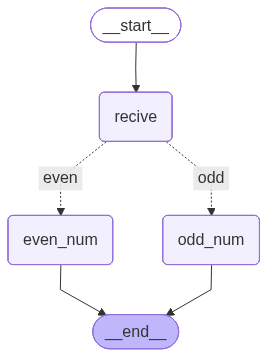

--- Testing with 8 ---
8 recived
[even_num] 8 is even
{'number': 8, 'result': ''}

--- Testing with 7 ---
7 recived
[odd_num] 7 is odd
{'number': 7, 'result': ''}


In [10]:
graph = builder.compile()

from IPython.display import Image, display

display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)

# --- Test with both an even and an odd number ---
print("--- Testing with 8 ---")
print(graph.invoke({"number": 8,  "result": ""}))

print()
print("--- Testing with 7 ---")
print(graph.invoke({"number": 7, "result": ""}))

# dynamic Routing

In [1]:
from typing import TypedDict, Literal
from langgraph.graph import StateGraph, START, END

In [2]:
class TaskState(TypedDict):
    task_type: str   
    input_data: str
    output: str

In [3]:
def dispatch(state : TaskState)->Literal['math_worker','text_worker',"fallback"]:
    task = state['task_type'].lower().strip()
    if task == 'math':
        return 'math_worker'
    elif task == 'text':
        return 'text_worker'
    else:
        'fallback'

In [4]:
def math_worker(state: TaskState) -> dict:
    try:
        result = str(eval(state["input_data"]))
    except Exception:
        result = "math error"
    print(f"  [math_worker] {state['input_data']} = {result}")
    return {"output": result}

def text_worker(state: TaskState) -> dict:
    result = state["input_data"].upper()
    print(f"  [text_worker] '{state['input_data']}' -> '{result}'")
    return {"output": result}

def fallback(state: TaskState) -> dict:
    result = f"Unknown task type: '{state['task_type']}'"
    print(f"  [fallback] {result}")
    return {"output": result}

In [8]:
builder = StateGraph(TaskState)

In [9]:
builder.add_node('math_worker',math_worker)
builder.add_node('text_worker',text_worker)
builder.add_node('fallback',fallback)


In [ ]:
builder.add_conditional_edges(
    START,      
    dispatch,
    {
        "math_worker": "math_worker",
        "text_worker": "text_worker",
        "fallback":    "fallback",
    }
)

builder.add_edge("math_worker", END)
builder.add_edge("text_worker", END)
builder.add_edge("fallback",    END)

graph = builder.compile()


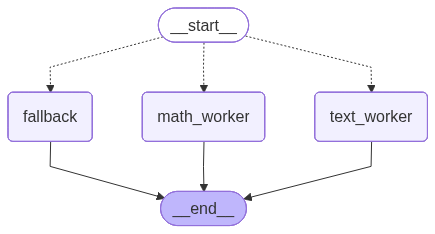

In [11]:
from IPython.display import Image, display

display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)

In [ ]:
tasks = [
    {"task_type": "math",    "input_data": "3 * 7 + 2",    "output": ""},
    {"task_type": "text",    "input_data": "hello world",  "output": ""},
    {"task_type": "unknown", "input_data": "do something", "output": ""},
]
        
for task in tasks:
    print(f"Task: {task['task_type']!r}")
    out = graph.invoke(task)
    print(f"  Result: {out['output']}")
    print()

Task: 'math'
  [math_worker] 3 * 7 + 2 = 23
  Result: 23

Task: 'text'
  [text_worker] 'hello world' -> 'HELLO WORLD'
  Result: HELLO WORLD

Task: 'unknown'


KeyError: None